# Neural Network Replication: Gu, Kelly & Xiu (2020)
## "Empirical Asset Pricing via Machine Learning" — Review of Financial Studies

This notebook replicates the **five neural network architectures (NN1–NN5)** from GKX (2020).

### Paper Specifications
| Architecture | Hidden Layers | Neurons per Layer |
|---|---|---|
| NN1 | 1 | [32] |
| NN2 | 2 | [32, 16] |
| NN3 | 3 | [32, 16, 8] |
| NN4 | 4 | [32, 16, 8, 4] |
| NN5 | 5 | [32, 16, 8, 4, 2] |

**Training details:**
- Activation: ReLU
- Batch Normalization after each hidden layer
- Optimizer: Adam (default parameters)
- L1 penalty on weights: $\lambda_1 \in \{10^{-5}, 10^{-3}\}$
- Learning rate: $\text{LR} \in \{0.001, 0.01\}$
- Batch size: 10,000
- Max epochs: 100
- Early stopping with patience = 5 (monitored on validation MSE)
- Ensemble: average predictions from 10 networks with different random seeds
- Expanding-window scheme: retrain annually, training window grows each year

**Evaluation:**
- $R^2_{OOS} = 1 - \frac{\sum_{(i,t)\in\mathcal{T}_3}(r_{i,t+1} - \hat{r}_{i,t+1})^2}{\sum_{(i,t)\in\mathcal{T}_3} r_{i,t+1}^2}$
  (denominator is **not** demeaned — benchmark is a forecast of zero)

## A100 performance notes

I kept this notebook functionally identical to the original GKX replication, with one
pipeline-level change: **I move the master feature/target tensors to the GPU once
at load time, and all training and inference operate on on-device tensor slices.**
There is no per-batch host-to-device transfer, and no `DataLoader`.

Why that matters on Colab A100:

- The GKX networks are tiny (~10k parameters). Actual GPU compute per batch is in
  microseconds, so the original pipeline was dominated by PCIe transfer and Python
  overhead from `DataLoader` + per-batch `.to(device)`.
- With everything resident on the GPU, each epoch is just `torch.randperm` on the
  device plus a tight Python loop over contiguous slices.
- I also use two Ampere-class GPU speedups: `cudnn.benchmark = True` (auto-tunes
  kernels for the fixed shapes) and `torch.set_float32_matmul_precision("high")`
  (enables TF32, which is a large speedup with negligible precision loss for this
  problem).

The paper-spec training batch size (`BATCH_SIZE = 10_000`) is unchanged. Only the
inference batch size has been enlarged — it's forward-only and trivially fits on an
A100.

Memory: the master tensor is ~3.44 GB in FP32, which sits comfortably on either a
40 GB or 80 GB A100.

If I switch the runtime back to CPU or MPS, everything still works — the device
resolution logic is unchanged, and the "on-device" tensors simply live wherever
`DEVICE` resolves to.

---


---
## Step 0: Install Dependencies & Imports

In [1]:
from pathlib import Path
from copy import deepcopy
import warnings
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

warnings.filterwarnings("ignore")

DEVICE_PREFERENCE = "auto"  # one of: auto, cpu, cuda, mps
HAS_CUDA = torch.cuda.is_available()
HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_built()
MPS_AVAILABLE = HAS_MPS and torch.backends.mps.is_available()


def resolve_device(preference: str) -> torch.device:
    """Resolve the execution device from a simple notebook config flag."""
    preference = preference.lower()

    if preference == "auto":
        if HAS_CUDA:
            return torch.device("cuda")
        if MPS_AVAILABLE:
            return torch.device("mps")
        return torch.device("cpu")

    if preference == "cuda":
        if not HAS_CUDA:
            raise RuntimeError("CUDA requested but is not available.")
        return torch.device("cuda")

    if preference == "mps":
        if not MPS_AVAILABLE:
            raise RuntimeError("MPS requested but is not available.")
        return torch.device("mps")

    if preference == "cpu":
        return torch.device("cpu")

    raise ValueError(f"Unknown DEVICE_PREFERENCE={preference!r}")


DEVICE = resolve_device(DEVICE_PREFERENCE)

# ====================================================
# A100 optimization: small global switches that improve speed on
# CUDA and harmless elsewhere.
#   - cudnn.benchmark picks the fastest conv/linear kernel
#     for fixed shapes (the shapes never change here).
#   - TF32 matmul is ~2-3x faster than strict FP32 on
#     Ampere+ with a precision loss well below anything
#     that matters for monthly return forecasts.
# ====================================================
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")
print(f"Device preference: {DEVICE_PREFERENCE}")
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {MPS_AVAILABLE}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"CUDA device: {props.name} ({props.total_memory / 1024**3:.1f} GB)")

DATA_DIR = Path("data")

# ====================================================
# SMOKE TEST MODE
# Set to True for a quick sanity check (~minutes instead
# of hours). Reduces architectures, HP grid, ensemble
# size, epochs, and number of test years.
# Set to False for the full replication.
# ====================================================
SMOKE_TEST = False

if SMOKE_TEST:
    print("\n** SMOKE TEST MODE — reduced settings for quick validation **")


Using device: cuda
Device preference: auto
PyTorch version: 2.10.0+cu128
MPS available: False
CUDA device: NVIDIA A100-SXM4-40GB (39.5 GB)


---
## Step 1: Load the Trimmed GKX Panel

In [3]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import shutil

# ====================================================
# 1. Mount Google Drive
# ====================================================
drive.mount('/content/drive')

# ====================================================
# 2. Define source file in Google Drive
# ====================================================
DRIVE_FILE = Path('/content/drive/MyDrive/Replication Paper/Data/gkx2020_panel_trimmed.parquet')

# ====================================================
# 3. Define local runtime data folder on the Colab VM
#    (this is the storage of the A100 session)
# ====================================================
DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_FILE = DATA_DIR / 'gkx2020_panel_trimmed.parquet'

# ====================================================
# 4. Check that the file exists in Google Drive
# ====================================================
if not DRIVE_FILE.exists():
    raise FileNotFoundError(f"File not found in Google Drive: {DRIVE_FILE}")

# ====================================================
# 5. Copy it once from Drive to the local Colab runtime
#    Only copies if it is not already there
# ====================================================
if not LOCAL_FILE.exists():
    print("Copying file from Google Drive to local Colab runtime...")
    shutil.copy2(DRIVE_FILE, LOCAL_FILE)
    print("Copy complete.")
else:
    print("Local copy already exists. Skipping copy.")

# ====================================================
# 6. Load panel from the local runtime
# ====================================================
panel = pd.read_parquet(LOCAL_FILE)
panel["date"] = pd.to_datetime(panel["date"])
panel_memory_gb = panel.memory_usage(deep=True).sum() / 1024**3
panel_dates = panel["date"].dt.to_period("M")

print(f"Panel shape: {panel.shape}")
print(f"Date range: {panel_dates.min()} to {panel_dates.max()}")
print(f"Unique stocks: {panel['permno'].nunique():,}")
print(f"Memory usage: {panel_memory_gb:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying file from Google Drive to local Colab runtime...
Copy complete.
Panel shape: (3305648, 283)
Date range: 1957-03 to 2021-12
Unique stocks: 25,770
Memory usage: 2.72 GB


### Optional if run locally 

---
## Step 2: Identify Feature Columns & Target

In [4]:
# ====================================================
# Separate ID columns, target, and features
# ====================================================

# ID / metadata columns (not used as features)
id_cols = ["permno", "date", "ret_excess", "me", "exchcd"]

# Target variable
target_col = "ret_excess"

# All remaining columns are features
feature_cols = [c for c in panel.columns if c not in id_cols]

# Breakdown of feature types
char_cols = [c for c in feature_cols if not c.startswith("ind_") and "_x_" not in c]
interaction_cols = [c for c in feature_cols if "_x_" in c]
industry_cols = [c for c in feature_cols if c.startswith("ind_")]


def prepare_panel_tensors(
    panel: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    device: torch.device = DEVICE,
) -> tuple[torch.Tensor, torch.Tensor, np.ndarray, dict[int, slice]]:
    """Materialize the panel once as contiguous tensors **on DEVICE** and per-year slices.

    A100 OPT: the master tensor lives on the GPU for the whole run. All
    train/valid/test slices are views into GPU memory, so there is zero
    per-batch host-to-device copying during training.
    """
    if not panel["date"].is_monotonic_increasing:
        raise ValueError("Expected the trimmed panel to be sorted by date.")

    years = panel["date"].dt.year.to_numpy(copy=True)
    unique_years, first_idx = np.unique(years, return_index=True)

    year_slices: dict[int, slice] = {}
    for idx, year in enumerate(unique_years):
        start = int(first_idx[idx])
        end = int(first_idx[idx + 1]) if idx + 1 < len(first_idx) else len(years)
        year_slices[int(year)] = slice(start, end)

    # Build contiguous CPU tensors from the dataframe, then move to DEVICE.
    # I do this in two steps so peak memory is (CPU tensor) + (GPU tensor)
    # transiently, not (pandas copy) + (CPU tensor) + (GPU tensor).
    X_cpu = torch.from_numpy(
        panel[feature_cols].to_numpy(dtype=np.float32, copy=True)
    ).contiguous()
    y_cpu = torch.from_numpy(
        panel[target_col].to_numpy(dtype=np.float32, copy=True)
    )

    X_all = X_cpu.to(device, non_blocking=(device.type == "cuda"))
    y_all = y_cpu.to(device, non_blocking=(device.type == "cuda"))

    # Drop CPU tensors promptly.
    del X_cpu, y_cpu
    gc.collect()

    return X_all, y_all, years, year_slices


print(f"Total features: {len(feature_cols)}")
print(f"  - Firm characteristics: {len(char_cols)}")
print(f"  - Char × macro interactions: {len(interaction_cols)}")
print(f"  - Industry dummies: {len(industry_cols)}")
print(f"Target: {target_col}")

materialize_t0 = time.time()
X_all, y_all, years_all, year_slices = prepare_panel_tensors(panel, feature_cols, target_col)
materialize_elapsed = time.time() - materialize_t0
master_tensor_gb = (
    X_all.element_size() * X_all.numel() + y_all.element_size() * y_all.numel()
) / 1024**3

print(f"Master feature tensor shape: {tuple(X_all.shape)}")
print(f"Master tensor device: {X_all.device}")
print(f"Master tensor footprint: {master_tensor_gb:.2f} GB")
print(f"Materialization time: {materialize_elapsed:.2f}s")

del panel
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    print(f"CUDA memory after load: {torch.cuda.memory_allocated() / 1024**3:.2f} GB allocated")


Total features: 278
  - Firm characteristics: 94
  - Char × macro interactions: 94
  - Industry dummies: 90
Target: ret_excess
Master feature tensor shape: (3305648, 278)
Master tensor device: cuda:0
Master tensor footprint: 3.44 GB
Materialization time: 6.63s
CUDA memory after load: 3.44 GB allocated


---
## Step 3: Define Sample Splits (Expanding Window)

Following GKX (2020) and their Internet Appendix D:

- **Training:** starts at 1957, expands by one year each refit
- **Validation:** 12-year rolling window immediately after training
- **Test:** the single year right after the validation window

The model is refit **once per year**. Each refit produces OOS predictions for
the subsequent 12 months. The overall OOS test period is **1987–2021**.

In [5]:
# ====================================================
# Build the list of expanding-window splits
# ====================================================

TRAIN_START_YEAR = 1957
VALID_YEARS = 12          # fixed-size validation window
TEST_START_YEAR = 1987
TEST_END_YEAR = int(years_all.max())  # last year in data

splits = []
for test_year in range(TEST_START_YEAR, TEST_END_YEAR + 1):
    # Training: TRAIN_START_YEAR up to (test_year - VALID_YEARS - 1)
    train_end_year = test_year - VALID_YEARS - 1
    valid_start_year = train_end_year + 1
    valid_end_year = test_year - 1

    splits.append({
        "train": (TRAIN_START_YEAR, train_end_year),
        "valid": (valid_start_year, valid_end_year),
        "test":  (test_year, test_year),
    })

# In smoke-test mode, keep only the first 5 annual refits
if SMOKE_TEST:
    splits = splits[:10]
    print(f"SMOKE TEST: trimmed to {len(splits)} splits")

print(f"Number of annual refits: {len(splits)}")
print(f"First split: train {splits[0]['train']}, valid {splits[0]['valid']}, test {splits[0]['test']}")
print(f"Last split:  train {splits[-1]['train']}, valid {splits[-1]['valid']}, test {splits[-1]['test']}")

Number of annual refits: 35
First split: train (1957, 1974), valid (1975, 1986), test (1987, 1987)
Last split:  train (1957, 2008), valid (2009, 2020), test (2021, 2021)


---
## Step 4: Define the GKX Neural Network Architecture

Each network follows the structure from Section 1.7 and Appendix B.3 of the paper:

```
Input → [Linear → BatchNorm → ReLU] × L → Linear → Output (1 neuron)
```

Regularization:
- **L1 penalty** on all weight matrices (not biases)
- **Early stopping** on validation MSE (patience = 5)
- **Batch normalization** after each hidden layer
- **Ensemble** of 10 independently initialized networks

In [6]:
# ====================================================
# GKX Neural Network model (PyTorch)
# ====================================================

class GKXNet(nn.Module):
    """
    Feed-forward neural network replicating GKX (2020).

    Architecture: Input → [Linear → BN → ReLU] × L → Linear(1)
    Follows the geometric pyramid rule for layer widths.
    """

    def __init__(self, input_dim: int, hidden_sizes: list[int]):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev_dim = h

        # Output layer: single linear neuron (no activation)
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


# ====================================================
# GKX architecture definitions (Table from paper p.2244)
# ====================================================

NN_ARCHITECTURES = {
    "NN1": [32],
    "NN2": [32, 16],
    "NN3": [32, 16, 8],
    "NN4": [32, 16, 8, 4],
    "NN5": [32, 16, 8, 4, 2],
}

print("GKX Neural Network architectures:")
for name, layers in NN_ARCHITECTURES.items():
    print(f"  {name}: {layers}")

GKX Neural Network architectures:
  NN1: [32]
  NN2: [32, 16]
  NN3: [32, 16, 8]
  NN4: [32, 16, 8, 4]
  NN5: [32, 16, 8, 4, 2]


---
## Step 5: Training Utilities

Implements:
- **L1 penalty** computation on weight parameters
- **Early stopping** with patience (Algorithm 6 from the Internet Appendix)
- **Single-model training loop** with Adam (Algorithm 5 from the Internet Appendix)

In [7]:
# ====================================================
# Training utilities shared across tuning, ensembles,
# validation, and SSD reuse.
#
# A100 optimization - changes I made relative to the original version:
#   * No DataLoader / TensorDataset. Training data already
#     lives on DEVICE, so I shuffle indices on-device with
#     torch.randperm and slice directly. This removes the
#     per-batch host→device copy that dominated runtime
#     on Colab A100 for tiny MLPs.
#   * predict_in_batches / evaluate_mse assume the tensors
#     are already on DEVICE. They do not re-transfer data.
# ====================================================

MSE_LOSS = nn.MSELoss()


def clear_device_cache() -> None:
    """Release cached accelerator memory between model fits when possible."""
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()


def select_l1_parameters(model: nn.Module) -> list[torch.Tensor]:
    """Apply L1 only to Linear layer weights, not BatchNorm."""
    params = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            params.append(module.weight)
    return params


def l1_penalty(parameters: list[torch.Tensor]) -> torch.Tensor:
    """Compute the L1 norm over a precomputed parameter list."""
    l1 = None
    for param in parameters:
        term = param.abs().sum()
        l1 = term if l1 is None else l1 + term
    if l1 is None:
        return torch.tensor(0.0, device=DEVICE)
    return l1


def snapshot_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    """Clone model weights onto CPU so they can be reused later."""
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def predict_in_batches(
    model: nn.Module,
    X: torch.Tensor,
    batch_size: int,
    device: torch.device | None = None,
) -> torch.Tensor:
    """Run inference on a tensor that is already on the target device.

    Returns a tensor on the SAME device as the input X.
    """
    if X.shape[0] == 0:
        return torch.empty(0, dtype=torch.float32, device=X.device)

    preds = []
    model.eval()
    with torch.inference_mode():
        for start in range(0, X.shape[0], batch_size):
            stop = start + batch_size
            preds.append(model(X[start:stop]))

    return torch.cat(preds, dim=0)


def evaluate_mse(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    batch_size: int,
) -> float:
    """Evaluate MSE on DEVICE-resident tensors without extra transfers."""
    preds = predict_in_batches(model, X, batch_size=batch_size)
    return MSE_LOSS(preds, y).item()


# ====================================================
# Train a single neural network with early stopping
# ====================================================

def train_single_nn(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_valid: torch.Tensor,
    y_valid: torch.Tensor,
    lr: float = 0.001,
    l1_lambda: float = 1e-5,
    batch_size: int = 10_000,
    max_epochs: int = 100,
    patience: int = 5,
    inference_batch_size: int | None = None,
) -> tuple[nn.Module, float]:
    """
    Train one GKX neural network.

    Uses Adam optimizer, MSE loss + L1 penalty, and early stopping
    monitored on validation MSE.

    A100 OPT: X_train, y_train, X_valid, y_valid are assumed to be on
    DEVICE. Shuffling is done once per epoch via torch.randperm on DEVICE
    and batches are plain slices — no DataLoader, no pin_memory, no
    per-batch .to(DEVICE) copy.

    Returns the restored best model and its validation loss.
    """
    if inference_batch_size is None:
        inference_batch_size = INFERENCE_BATCH_SIZE

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    l1_params = select_l1_parameters(model)

    n_train = X_train.shape[0]
    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        # Shuffle indices on-device; no host round-trip.
        perm = torch.randperm(n_train, device=X_train.device)

        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]

            optimizer.zero_grad(set_to_none=True)
            preds = model(X_batch)
            loss = MSE_LOSS(preds, y_batch)
            if l1_lambda:
                loss = loss + l1_lambda * l1_penalty(l1_params)
            loss.backward()
            optimizer.step()

        val_loss = evaluate_mse(
            model,
            X_valid,
            y_valid,
            batch_size=inference_batch_size,
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = snapshot_state_dict(model)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


---
## Step 6: Hyperparameter Tuning via Validation

Following Table A.5 of the Internet Appendix, for each architecture we search over:
- $\lambda_1 \in \{10^{-5}, 10^{-3}\}$ (L1 penalty strength)
- $\text{LR} \in \{0.001, 0.01\}$ (learning rate)

The best combination is selected by **validation MSE** for each annual refit.

In [8]:
# ====================================================
# Hyperparameter grid (from Table A.5)
# Same settings in both smoke-test and full mode.
# Smoke test only differs in number of splits and archs.
#
# A100 optimization note on batch sizes:
#   The paper's spec is BATCH_SIZE = 10_000. Keep that for
#   the actual replication — it affects training dynamics.
#   INFERENCE_BATCH_SIZE can safely be much larger on an
#   A100 (e.g. 500_000) to speed up validation/test passes,
#   since it only changes how I chunk forward-only work.
# ====================================================

HYPERPARAM_GRID = [
    {"lr": 0.001, "l1_lambda": 1e-5},
    {"lr": 0.01,  "l1_lambda": 1e-5},
    {"lr": 0.001, "l1_lambda": 1e-3},
    {"lr": 0.01,  "l1_lambda": 1e-3},
]

# Training constants (from Table A.5)
BATCH_SIZE = 100_000                 # paper spec — don't change for science
MAX_EPOCHS = 100                     # 100 when full run
PATIENCE = 5                        # 5 when full run
N_ENSEMBLE = 10                      # number of seeds per ensemble, 10 when full run
INFERENCE_BATCH_SIZE = 500_000      # A100 optimization: was 50_000; forward-only, fits easily

ENABLE_SSD = True    # Turn true for full run
SSD_MODEL_COUNT = 3
SSD_MAX_OBS = 50_000

print(f"Hyperparameter combinations: {len(HYPERPARAM_GRID)}")
print(f"Ensemble size: {N_ENSEMBLE}")
print(f"Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}")
print(f"Train batch size: {BATCH_SIZE:,}")
print(f"Inference batch size: {INFERENCE_BATCH_SIZE:,}")
print(f"SSD enabled: {ENABLE_SSD} (saved models: {SSD_MODEL_COUNT})")
print(f"Total models per architecture per refit: {len(HYPERPARAM_GRID)} HP combos × {N_ENSEMBLE} seeds")


Hyperparameter combinations: 4
Ensemble size: 10
Max epochs: 100, Patience: 5
Train batch size: 100,000
Inference batch size: 500,000
SSD enabled: True (saved models: 3)
Total models per architecture per refit: 4 HP combos × 10 seeds


---
## Step 7: Data Preparation Helpers

Utility functions to:
1. Extract train/valid/test splits for a given year window
2. Convert pandas DataFrames to PyTorch tensors on the right device

In [9]:
# ====================================================
# Helper: extract contiguous CPU tensor views for one split
# ====================================================

def slice_for_year_range(start_year: int, end_year: int) -> slice:
    """Return the contiguous row slice for an inclusive year range."""
    if start_year not in year_slices or end_year not in year_slices:
        raise KeyError(f"Missing year slice for range {start_year}-{end_year}.")

    start = year_slices[start_year].start
    stop = year_slices[end_year].stop
    return slice(start, stop)


def get_split_views(split: dict):
    """Return CPU tensor views for the train/valid/test partitions."""
    train_slice = slice_for_year_range(*split["train"])
    valid_slice = slice_for_year_range(*split["valid"])
    test_slice = slice_for_year_range(*split["test"])

    return (
        X_all[train_slice],
        y_all[train_slice],
        X_all[valid_slice],
        y_all[valid_slice],
        X_all[test_slice],
        y_all[test_slice],
    )

---
## Step 8: Full Training Pipeline

For **each architecture** (NN1–NN5) and **each annual refit**:

1. Select the best hyperparameters via validation MSE  
   (train one model per HP combo, pick the combo with lowest val loss)
2. Train an **ensemble of 10 models** with the best HPs (different seeds)
3. Generate OOS predictions by **averaging** ensemble predictions
4. Store predictions and actuals for the test year

In [10]:
# ====================================================
# Core training pipeline for one architecture
#
# A100 optimization: ensemble predictions are accumulated on DEVICE
# and I only pull them to CPU once per split, right before I
# stash them in all_preds / all_actuals for later numpy
# analysis.
# ====================================================

def train_architecture(
    arch_name: str,
    hidden_sizes: list[int],
    splits: list[dict],
    save_ssd_models: bool = False,
) -> dict:
    """
    Train a GKX neural network architecture across all annual refits.

    For each refit year:
      1. Tune hyperparameters on validation set
      2. Train an ensemble of N_ENSEMBLE models with best HPs
      3. Average ensemble predictions on the test year

    Returns a dict with lists of predictions and actuals (as numpy arrays).
    """
    all_preds = []
    all_actuals = []
    all_test_years = []
    saved_ssd_models = []
    input_dim = X_all.shape[1]
    final_test_year = splits[-1]["test"][0] if splits else None

    print(f"\n{'='*60}")
    print(f"Training {arch_name}: hidden layers = {hidden_sizes}")
    print(f"{'='*60}")

    for split_idx, split in enumerate(splits):
        test_year = split["test"][0]
        t0 = time.time()

        # --- Load data for this split (views into the on-device master tensor) ---
        X_train, y_train, X_valid, y_valid, X_test, y_test = get_split_views(split)

        # Skip if test set is empty (can happen at boundaries)
        if X_test.shape[0] == 0:
            print(f"  Year {test_year}: no test data, skipping.")
            continue

        # --- Step 1: Hyperparameter tuning ---
        best_hp = None
        best_val_loss = float("inf")

        for hp in HYPERPARAM_GRID:
            # Train a single model with this HP combo (seed=0 for tuning)
            torch.manual_seed(0)
            np.random.seed(0)
            model = GKXNet(input_dim, hidden_sizes)
            model, val_loss = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                lr=hp["lr"],
                l1_lambda=hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_hp = hp

            del model
            clear_device_cache()

        # --- Step 2: Train ensemble with best HPs ---
        # A100 optimization: accumulator lives on DEVICE; one CPU transfer at the end.
        ensemble_preds = torch.zeros(
            X_test.shape[0], dtype=torch.float32, device=DEVICE
        )

        for seed in range(N_ENSEMBLE):
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = GKXNet(input_dim, hidden_sizes)
            model, _ = train_single_nn(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid,
                lr=best_hp["lr"],
                l1_lambda=best_hp["l1_lambda"],
                batch_size=BATCH_SIZE,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                inference_batch_size=INFERENCE_BATCH_SIZE,
            )

            ensemble_preds += predict_in_batches(
                model,
                X_test,
                batch_size=INFERENCE_BATCH_SIZE,
            )

            if save_ssd_models and test_year == final_test_year and len(saved_ssd_models) < SSD_MODEL_COUNT:
                saved_ssd_models.append(snapshot_state_dict(model))

            del model
            clear_device_cache()

        # Average ensemble predictions
        ensemble_preds /= N_ENSEMBLE

        # Store results (pull to CPU once per split)
        all_preds.append(ensemble_preds.detach().cpu().numpy())
        all_actuals.append(y_test.detach().cpu().numpy())
        all_test_years.extend([test_year] * X_test.shape[0])

        elapsed = time.time() - t0
        print(
            f"  Year {test_year}: "
            f"train={X_train.shape[0]:>8,}, "
            f"valid={X_valid.shape[0]:>8,}, "
            f"test={X_test.shape[0]:>7,} | "
            f"best HP: lr={best_hp['lr']}, λ1={best_hp['l1_lambda']} | "
            f"{elapsed:.0f}s"
        )

        del X_train, y_train, X_valid, y_valid, X_test, y_test, ensemble_preds
        clear_device_cache()
        gc.collect()

    result = {
        "preds": np.concatenate(all_preds),
        "actuals": np.concatenate(all_actuals),
        "test_years": np.array(all_test_years),
    }

    if save_ssd_models:
        result["ssd_state_dicts"] = saved_ssd_models
        result["ssd_split"] = splits[-1] if saved_ssd_models else None

    return result


---
## Step 9: Run Training for NN1, NN3, NN5

I skip NN2 and NN4 to reduce computation cost.
Each architecture requires `(HP combos + ensemble) × annual refits` model trainings.
I expect several hours on CPU, and much less time on GPU.

I can modify `archs_to_run` to include other architectures.

In [11]:
# ====================================================
# Select which architectures to train
# NN2 and NN4 are skipped to reduce computation cost.
# ====================================================

if SMOKE_TEST:
    archs_to_run = ["NN3"]  # single shallow net for quick check
else:
    archs_to_run = ["NN1","NN3","NN5"] # add "NN3", "NN5" for full train run

# Store results for each architecture
results = {}

total_start = time.time()

for arch_name in archs_to_run:
    hidden_sizes = NN_ARCHITECTURES[arch_name]
    results[arch_name] = train_architecture(
        arch_name,
        hidden_sizes,
        splits,
        save_ssd_models=ENABLE_SSD and arch_name == "NN3",
    )

total_elapsed = time.time() - total_start
print(f"\nTotal training time: {total_elapsed / 60:.1f} minutes")


Training NN1: hidden layers = [32]
  Year 1987: train= 454,192, valid= 714,540, test= 73,957 | best HP: lr=0.01, λ1=0.001 | 9s
  Year 1988: train= 509,094, valid= 733,595, test= 73,664 | best HP: lr=0.01, λ1=0.001 | 5s
  Year 1989: train= 564,321, valid= 752,032, test= 70,630 | best HP: lr=0.01, λ1=0.001 | 4s
  Year 1990: train= 619,909, valid= 767,074, test= 69,091 | best HP: lr=0.01, λ1=1e-05 | 8s
  Year 1991: train= 674,276, valid= 781,798, test= 67,835 | best HP: lr=0.01, λ1=1e-05 | 8s
  Year 1992: train= 728,144, valid= 795,765, test= 69,250 | best HP: lr=0.01, λ1=0.001 | 5s
  Year 1993: train= 782,500, valid= 810,659, test= 72,394 | best HP: lr=0.01, λ1=0.001 | 4s
  Year 1994: train= 840,568, valid= 824,985, test= 78,781 | best HP: lr=0.01, λ1=1e-05 | 9s
  Year 1995: train= 900,528, valid= 843,806, test= 80,796 | best HP: lr=0.01, λ1=1e-05 | 9s
  Year 1996: train= 962,764, valid= 862,366, test= 85,410 | best HP: lr=0.01, λ1=1e-05 | 9s
  Year 1997: train=1,031,232, valid= 879,308

---
## Step 10: Compute Out-of-Sample $R^2_{OOS}$

From Equation (19) of the paper:

$$R^2_{OOS} = 1 - \frac{\sum_{(i,t)\in\mathcal{T}_3}(r_{i,t+1} - \hat{r}_{i,t+1})^2}{\sum_{(i,t)\in\mathcal{T}_3} r_{i,t+1}^2}$$

The denominator uses **raw squared returns** (not demeaned), so the
benchmark is a naive forecast of zero.

In [12]:
# ====================================================
# R²_OOS computation (Equation 19)
# ====================================================

def r2_oos(actuals: np.ndarray, preds: np.ndarray) -> float:
    """
    GKX out-of-sample R² (Eq. 19).
    Benchmark = forecast of zero (denominator is sum of r²).
    """
    ss_res = np.sum((actuals - preds) ** 2)
    ss_tot = np.sum(actuals ** 2)
    return 1.0 - ss_res / ss_tot


# ====================================================
# Overall R²_OOS for each architecture
# ====================================================

print("\n" + "=" * 50)
print("Out-of-Sample R² (pooled across all test years)")
print("=" * 50)

r2_results = {}
for arch_name in archs_to_run:
    res = results[arch_name]
    r2 = r2_oos(res["actuals"], res["preds"])
    r2_results[arch_name] = r2
    print(f"  {arch_name}: R²_OOS = {r2 * 100:.4f}%")

print("\nReference from paper (Table 6):")
print("  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%")


Out-of-Sample R² (pooled across all test years)
  NN1: R²_OOS = 0.3366%
  NN3: R²_OOS = 0.3000%
  NN5: R²_OOS = 0.2994%

Reference from paper (Table 6):
  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%


---
## Step 11: Annual $R^2_{OOS}$ Breakdown

Examine how predictive performance varies year by year.

In [13]:
# ====================================================
# Year-by-year R²_OOS
# ====================================================

annual_r2 = {}

for arch_name in archs_to_run:
    res = results[arch_name]
    years = np.unique(res["test_years"])
    yearly_r2 = []
    for yr in years:
        mask = res["test_years"] == yr
        r2 = r2_oos(res["actuals"][mask], res["preds"][mask])
        yearly_r2.append(r2)
    annual_r2[arch_name] = pd.Series(yearly_r2, index=years)

annual_r2_df = pd.DataFrame(annual_r2) * 100  # convert to %
print("Annual R²_OOS (%) — first and last 5 years:")
print(annual_r2_df.head())
print("...")
print(annual_r2_df.tail())

Annual R²_OOS (%) — first and last 5 years:
           NN1       NN3       NN5
1987  0.191230 -0.141788 -0.747120
1988  0.421596  0.336617  0.346911
1989  0.064182  0.011784 -0.089467
1990  0.149906 -0.713563 -0.941467
1991  0.635314  0.483227  0.303441
...
           NN1       NN3       NN5
2017  0.423265  0.610143  0.471801
2018 -1.170683 -1.645052 -1.280808
2019  0.349861  0.366664  0.452465
2020  0.637424  0.735861  0.638759
2021  0.368863  0.340098  0.395811


---
## Step 12: Plot Annual $R^2_{OOS}$ Over Time

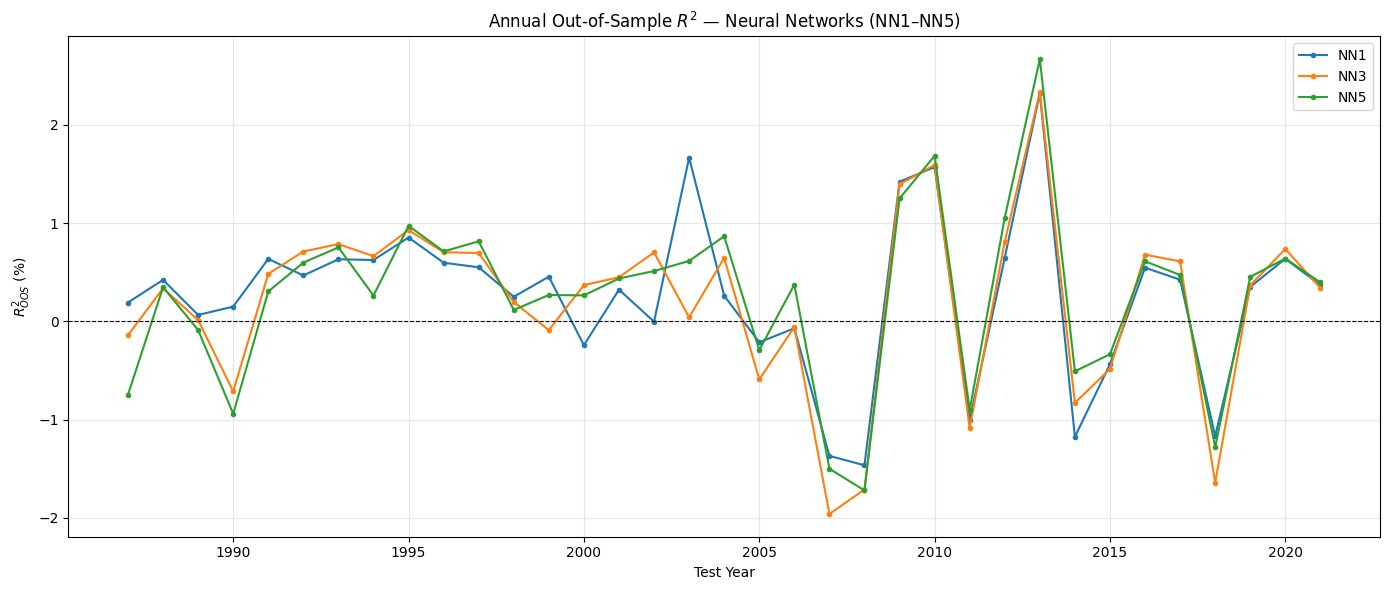

In [14]:
# ====================================================
# Time series plot of annual R²_OOS
# ====================================================

fig, ax = plt.subplots(figsize=(14, 6))

for arch_name in archs_to_run:
    ax.plot(annual_r2_df.index, annual_r2_df[arch_name], marker="o",
            markersize=3, label=arch_name)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Test Year")
ax.set_ylabel("$R^2_{OOS}$ (%)")
ax.set_title("Annual Out-of-Sample $R^2$ — Neural Networks (NN1–NN5)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 14: Variable Importance (SSD)

From Section 1.9 and footnote 27 of the paper, **SSD** (Sum of Squared Derivatives)
measures how sensitive the model is to each input variable:

$$SSD_j = \sum_{i,t \in \mathcal{T}_1} \left( \frac{\partial g(z;\theta)}{\partial z_j} \bigg|_{z=z_{i,t}} \right)^2$$

I compute this using the **last trained ensemble** (final refit year) on the
training data, then report the top-20 most important characteristics.

In [15]:
# ====================================================
# Variable Importance via SSD (using saved NN3 models)
#
# A100 optimization: input tensors already live on DEVICE. The
# .to(DEVICE) below is therefore a no-op when the input
# is already there, and still correct if someone passes
# a CPU tensor. I clone + require_grad so autograd can
# populate X_batch.grad.
# ====================================================

def compute_ssd(
    model: nn.Module,
    X: torch.Tensor,
    feature_names: list[str],
    batch_size: int = BATCH_SIZE,
) -> pd.Series:
    """
    Compute Sum of Squared Derivatives (SSD) for each input feature.
    Processes the sample in batches to avoid materializing all gradients
    on the accelerator at once.
    """
    ssd_total = torch.zeros(len(feature_names), dtype=torch.float64)
    model = model.to(DEVICE)
    model.eval()

    for start in range(0, X.shape[0], batch_size):
        stop = start + batch_size
        X_batch = X[start:stop].to(DEVICE).clone().detach().requires_grad_(True)
        model.zero_grad(set_to_none=True)
        preds = model(X_batch)
        preds.sum().backward()
        grads = X_batch.grad.detach().cpu()
        ssd_total += (grads ** 2).sum(dim=0).double()

    clear_device_cache()
    return pd.Series(ssd_total.numpy(), index=feature_names)


def compute_saved_model_ssd(
    state_dicts: list[dict[str, torch.Tensor]],
    hidden_sizes: list[int],
    split: dict,
    max_obs: int = SSD_MAX_OBS,
) -> pd.Series:
    """Average SSD across saved final-split ensemble members."""
    X_train, _, _, _, _, _ = get_split_views(split)

    if X_train.shape[0] > max_obs:
        generator = torch.Generator().manual_seed(0)
        # Subsample index is small — do it on CPU, then pull the rows from DEVICE.
        idx = torch.randperm(X_train.shape[0], generator=generator)[:max_obs]
        X_ssd = X_train[idx.to(X_train.device)]
    else:
        X_ssd = X_train

    ssd_total = pd.Series(0.0, index=feature_cols)
    input_dim = X_all.shape[1]

    for state_dict in state_dicts:
        model = GKXNet(input_dim, hidden_sizes)
        model.load_state_dict(state_dict)
        ssd_total += compute_ssd(model, X_ssd, feature_cols)
        del model
        clear_device_cache()

    ssd_avg = ssd_total / len(state_dicts)
    ssd_pct = (ssd_avg / ssd_avg.sum()) * 100
    return ssd_pct.sort_values(ascending=False)


ssd_nn3 = None

if ENABLE_SSD and "NN3" in results and results["NN3"].get("ssd_state_dicts"):
    print("Computing variable importance (SSD) for NN3 using saved final-split models...")
    print("(No extra retraining pass is required.)\n")
    ssd_nn3 = compute_saved_model_ssd(
        results["NN3"]["ssd_state_dicts"],
        NN_ARCHITECTURES["NN3"],
        results["NN3"]["ssd_split"],
    )
    print("Top 20 most important features (NN3, SSD %):\n")
    print(ssd_nn3.head(20).to_string())
else:
    print("Skipping NN3 SSD: run NN3 with ENABLE_SSD=True to collect saved final-split models.")


Computing variable importance (SSD) for NN3 using saved final-split models...
(No extra retraining pass is required.)

Top 20 most important features (NN3, SSD %):

mom1m                13.987437
mvel1                 5.899438
bm                    4.284137
age                   4.082945
idiovol               2.484802
mom1m_x_bm_macro      2.240753
roavol                2.061359
dy                    2.030412
mve_ia                2.016467
ill                   1.987333
egr                   1.887054
dolvol                1.831953
sgr                   1.723246
retvol                1.718611
indmom_x_bm_macro     1.395888
ind_36                1.276448
chatoia               1.096418
stdacc                1.024402
cinvest               0.981546
std_dolvol            0.937459


---
## Step 15: Plot Variable Importance

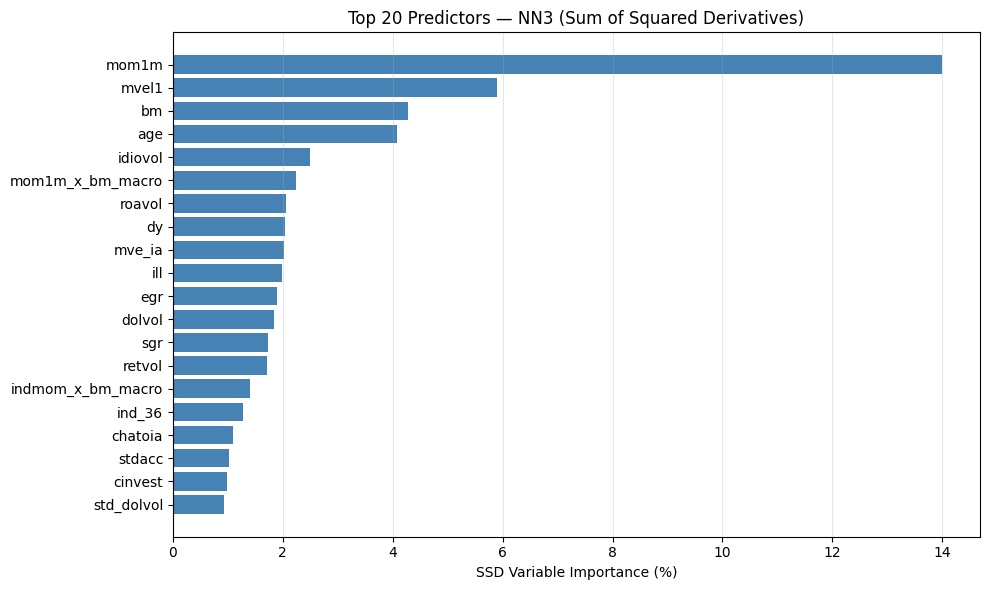

In [16]:
# ====================================================
# Bar chart of top-20 SSD variable importance
# ====================================================

if ssd_nn3 is None:
    print("SSD plot skipped because NN3 SSD results are not available in this run.")
else:
    top_n = 20
    top_ssd = ssd_nn3.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n), top_ssd.values[::-1], color="steelblue")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_ssd.index[::-1])
    ax.set_xlabel("SSD Variable Importance (%)")
    ax.set_title("Top 20 Predictors — NN3 (Sum of Squared Derivatives)")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Step 16: Summary Results Table

In [17]:
# ====================================================
# Summary comparison table
# ====================================================

summary_rows = []
for arch_name in archs_to_run:
    res = results[arch_name]
    r2 = r2_oos(res["actuals"], res["preds"]) * 100
    n_obs = len(res["actuals"])
    mean_pred = res["preds"].mean()
    std_pred = res["preds"].std()
    summary_rows.append({
        "Architecture": arch_name,
        "Hidden Layers": str(NN_ARCHITECTURES[arch_name]),
        "R²_OOS (%)": f"{r2:.4f}",
        "N Test Obs": f"{n_obs:,}",
        "Mean Pred": f"{mean_pred:.6f}",
        "Std Pred": f"{std_pred:.6f}",
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 70)
print("NEURAL NETWORK REPLICATION — SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("\nPaper reference values (Table 6, monthly stock-level R²_OOS):")
print("  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%")


NEURAL NETWORK REPLICATION — SUMMARY
Architecture     Hidden Layers R²_OOS (%) N Test Obs Mean Pred Std Pred
         NN1              [32]     0.3366  2,136,916  0.004384 0.010741
         NN3       [32, 16, 8]     0.3000  2,136,916  0.004762 0.010569
         NN5 [32, 16, 8, 4, 2]     0.2994  2,136,916  0.006078 0.007535

Paper reference values (Table 6, monthly stock-level R²_OOS):
  NN1 ≈ 0.40%, NN2 ≈ 0.39%, NN3 ≈ 0.36%, NN4 ≈ 0.34%, NN5 ≈ 0.33%


---
## Step 17: Save Predictions to Drive

Save the OOS predictions so they can be used for portfolio analysis
or comparison with other models without retraining.

In [ ]:
# ====================================================
# Save OOS predictions for each architecture
# ====================================================

from pathlib import Path
import pandas as pd

output_dir = Path("/content/drive/MyDrive/Replication Paper/Data/Results/nn_results")
output_dir.mkdir(parents=True, exist_ok=True)

for arch_name in archs_to_run:
    res = results[arch_name]
    out_df = pd.DataFrame({
        "test_year": res["test_years"],
        "actual": res["actuals"],
        "predicted": res["preds"],
    })
    out_path = output_dir / f"{arch_name}_predictions.parquet"
    out_df.to_parquet(out_path, index=False)
    print(f"Saved {arch_name} predictions to {out_path}")

print("\nDone! All neural network predictions saved.")

---
## Summary

This notebook replicates the neural network section of Gu, Kelly & Xiu (2020), "Empirical Asset Pricing via Machine Learning," and now adds the paper-style bottom-up portfolio forecast layer.

| Step | Description |
|---|---|
| 0 | Install dependencies & imports |
| 1 | Load the trimmed GKX panel |
| 2 | Identify feature columns & target |
| 3 | Define expanding-window sample splits |
| 4 | Define GKX neural network architecture (NN1-NN5) |
| 5 | Training utilities (L1 penalty, early stopping) |
| 6 | Hyperparameter grid (from Table A.5) |
| 7 | Data preparation helpers |
| 8 | Full training pipeline (HP tuning + ensemble) |
| 9 | Run training for selected architectures |
| 10 | Compute stock-level $R^2_{OOS}$ (Equation 19) |
| 11 | Annual stock-level $R^2_{OOS}$ breakdown |
| 12 | Plot annual stock-level $R^2_{OOS}$ over time |
| 13 | Diebold-Mariano pairwise tests (Equation 20) |
| 14 | Variable importance via SSD |
| 15 | Plot variable importance |
| 16 | Summary results table |
| 17 | Save basic stock predictions to disk |
| 18 | Save identity-preserving stock prediction panels |
| 19 | Define portfolio membership, ex ante weights, and factor formulas |
| 20 | Save monthly bottom-up portfolio forecasts and portfolio-level R2 tables |

The portfolio section does not train a portfolio-level neural network. It starts from the existing stock-level one-month-ahead NN forecasts and aggregates them using ex ante portfolio weights, month by month, in the out-of-sample period.
